### **Useful Packages**

In [ ]:
import numpy as np
import pandas as pd

import astropy.units as u
import astropy.constants as c
import math

import matplotlib.pyplot as plt
from scipy.stats import linregress

from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist

### **Insight Data Uploading**

**Note:** No need to download the files

**Data Source:** https://dataverse.ipgp.fr/dataset.xhtml?persistentId=doi:10.18715/IPGP.2023.llxn7e6d

**Paper Source:** https://doi.org/10.1038/s41586-023-06586-4

In [ ]:
!wget https://dataverse.ipgp.fr/api/access/datafile/3694

--2025-10-04 21:38:17--  https://dataverse.ipgp.fr/api/access/datafile/3694
Resolving dataverse.ipgp.fr (dataverse.ipgp.fr)... 194.254.225.55
Connecting to dataverse.ipgp.fr (dataverse.ipgp.fr)|194.254.225.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4862826 (4.6M) [application/zip]
Saving to: ‘3694’

3694                100%[===================>]   4.64M   544KB/s    in 12s     

2025-10-04 21:38:30 (397 KB/s) - ‘3694’ saved [4862826/4862826]



### **Unzip Data**

In [ ]:
import zipfile

with zipfile.ZipFile('3694', 'r') as zip:
  zip.extractall('.')

### **Loading Files**

In [ ]:
import os

files = os.listdir('./LSL_Models')

In [ ]:
dfs = {}

df_columns = ['Depth[km]', 'Vp[km/s]', 'Vs[km/s]',
              'Rho[g/cm3]', 'T[K]', 'g[m/s2]', 'P[Pa]']

for file_name in files:

    model_number = file_name.replace('Model_', '').replace('.txt', '')

    file_path = os.path.join('./LSL_Models', file_name)

    df_ = pd.read_csv(file_path, sep = '\s+',
                     comment = '#', names = df_columns)

    dfs[model_number] = df_

In [ ]:
N = 1000
N = str(N)
dfs[N].head(10)

,Depth[km],Vp[km/s],Vs[km/s],Rho[g/cm3],T[K],g[m/s2],P[Pa]
0,0.000,3.6248,2.1860,1.6585,273.1500,3.7291,0.000000e+00
1,12.179,3.6248,2.1860,1.6585,322.7976,3.7390,7.532242e+07
2,12.179,4.5449,2.7408,2.0794,322.7976,3.7390,7.532242e+07
3,28.674,4.5449,2.7408,2.0794,390.0409,3.7469,2.035651e+08
4,28.674,5.2773,3.1825,2.4145,390.0409,3.7469,2.035651e+08
5,45.174,5.2773,3.1825,2.4145,457.3095,3.7504,3.528437e+08
6,45.174,7.9976,4.5437,3.5189,457.3095,3.7504,3.528437e+08
7,55.001,7.9894,4.5336,3.5186,497.3704,3.7434,4.825233e+08
8,64.827,7.9808,4.5233,3.5181,537.4314,3.7365,6.119472e+08
9,74.654,7.9718,4.5128,3.5176,577.4923,3.7296,7.411140e+08


## **Finding Crust/Mantle Transition Depth**


**Criteria**: By calculating the density gradient $d\rho/dr$ and finding the maximum value for it.



In [ ]:
transition_rhos = {}
transition_depths = {}

# Over all models
for n, df in dfs.items():

  # Taking 40-60 Depth Range
  df_range = df[(40 <= df['Depth[km]']) & (df['Depth[km]'] < 60)].copy()

  # Computing Gradient
  drho_dr = df_range['Rho[g/cm3]'].diff()/df_range['Depth[km]'].diff()

  # Taking Density for Maximum Gradient
  transition_rhos[n] = df_range.loc[drho_dr.idxmax(), 'Rho[g/cm3]']

  # Taking Depth for Maximum Gradient
  transition_depths[n] = df_range.loc[drho_dr.idxmax(), 'Depth[km]']

## **Selecting Crust Data**

In [ ]:
df_crust = {}

# Over all models
for n, df in dfs.items():

  # Just for Crust
  condition = (df['Depth[km]'] <= transition_depths[n])

  df_crust[n] = df[condition].copy()

In [ ]:
dfs['1000'].head(10)

,Depth[km],Vp[km/s],Vs[km/s],Rho[g/cm3],T[K],g[m/s2],P[Pa]
0,0.000,3.6248,2.1860,1.6585,273.1500,3.7291,0.000000e+00
1,12.179,3.6248,2.1860,1.6585,322.7976,3.7390,7.532242e+07
2,12.179,4.5449,2.7408,2.0794,322.7976,3.7390,7.532242e+07
3,28.674,4.5449,2.7408,2.0794,390.0409,3.7469,2.035651e+08
4,28.674,5.2773,3.1825,2.4145,390.0409,3.7469,2.035651e+08
5,45.174,5.2773,3.1825,2.4145,457.3095,3.7504,3.528437e+08
6,45.174,7.9976,4.5437,3.5189,457.3095,3.7504,3.528437e+08
7,55.001,7.9894,4.5336,3.5186,497.3704,3.7434,4.825233e+08
8,64.827,7.9808,4.5233,3.5181,537.4314,3.7365,6.119472e+08
9,74.654,7.9718,4.5128,3.5176,577.4923,3.7296,7.411140e+08


## **Pressure Profile**

In [ ]:
#Función integradora
def sistema(y, r,f_rho):
  G = c.G.value

  rho = f_rho(r)
  g, m, P = y

  dm = 4*np.pi*(r**2)*rho
  dg = 4*np.pi*G*rho - (2*G*m/(r**3))
  dP = -rho*g
  return np.array([dg, dm, dP])


R_mars = 0.533*c.R_earth.value

# Valores superficiales
P0_mars = 600 # Pa #CAMBIAR ESTO
m0 = 0.107*c.M_earth.value
g0 = (c.G.value*m0/((R_mars)**2)) #CAMBIAR ESTO

# Condiciones Iniciales
y0 = np.array([g0 , m0, P0_mars])

# Over all models in Crust
for n, df in df_crust.items():

  rhos = df['Rho[g/cm3]'].values*1e3 # kg/m3
  radius = R_mars - df['Depth[km]'].values*1e3 # m

  #Organización de datos para el interpolador
  sort_indices = np.argsort(radius)
  radius_interp = radius[sort_indices] #usamos este
  rhos_interp = rhos[sort_indices]
  # Interpoladores
  f_rho = interp1d(radius_interp,
                   rhos_interp,
                   bounds_error=False,
                   fill_value = (rhos_interp[0], rhos_interp[-1]))

  #Solución al sistema
  sol = odeint(sistema, y0, radius,args=(f_rho,)).T
  # Pressure
  df['P_int[Pa]'] = sol[2]

In [ ]:
df_crust['1000']

,Depth[km],Vp[km/s],Vs[km/s],Rho[g/cm3],T[K],g[m/s2],P[Pa],P_int[Pa]
0,0.000,3.6248,2.1860,1.6585,273.1500,3.7291,0.000000e+00,6.000000e+02
1,12.179,3.6248,2.1860,1.6585,322.7976,3.7390,7.532242e+07,8.409899e+07
2,12.179,4.5449,2.7408,2.0794,322.7976,3.7390,7.532242e+07,8.409899e+07
3,28.674,4.5449,2.7408,2.0794,390.0409,3.7469,2.035651e+08,2.084907e+08
4,28.674,5.2773,3.1825,2.4145,390.0409,3.7469,2.035651e+08,2.084907e+08
5,45.174,5.2773,3.1825,2.4145,457.3095,3.7504,3.528437e+08,3.460000e+08
6,45.174,7.9976,4.5437,3.5189,457.3095,3.7504,3.528437e+08,3.460000e+08


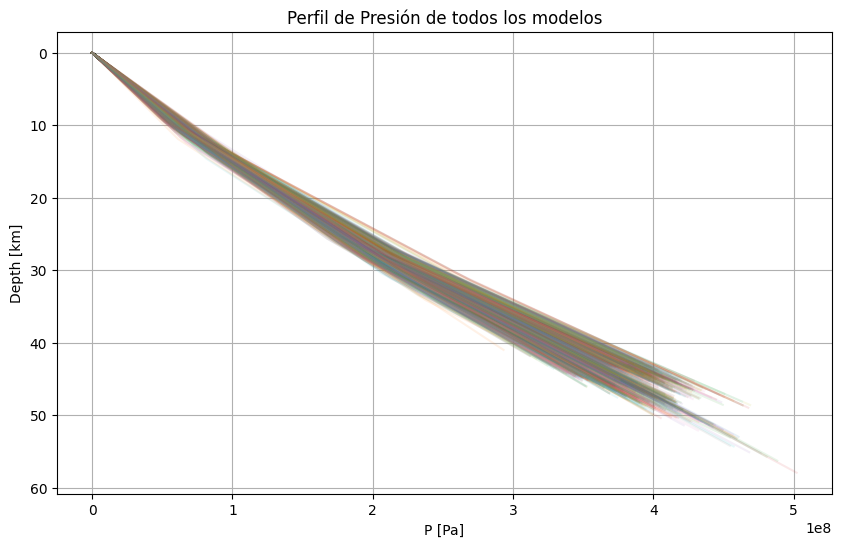

In [ ]:
plt.figure(figsize = (10, 6))

for n, df in df_crust.items():
  plt.plot(df['P[Pa]'], df['Depth[km]'], alpha = 0.1)

plt.title('Perfil de Presión de todos los modelos')
plt.ylabel('Depth [km]')
plt.xlabel('P [Pa]')

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

Ajuste lineal de la presión

In [ ]:
from scipy.stats import linregress
P_slopes = {}
for n, df in df_crust.items():
  x = pd.to_numeric(df['Depth[km]']*1e3, errors='coerce')
  y = pd.to_numeric(df['P[Pa]'], errors='coerce')

  mask_valid = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
  P_0 = 0
  x_clean = x[mask_valid].values
  y_clean = y[mask_valid].values


  fit_P = linregress(x_clean, y_clean)  # ajusta con los datos limpios
  P_slopes[n] = fit_P.slope
  df['P_lin[Pa]'] = fit_P.slope*df['Depth[km]']*1e3 + 0

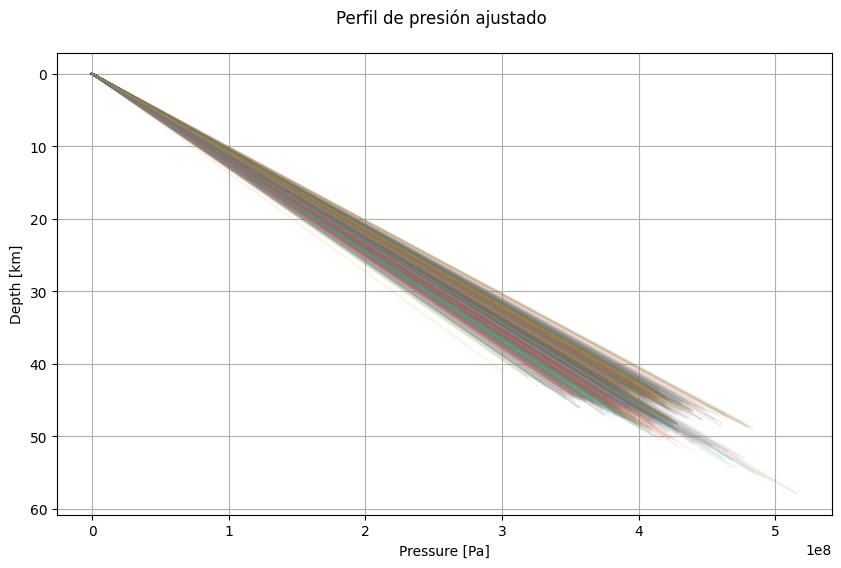

In [ ]:
plt.figure(figsize = (10, 6))

for n, df in df_crust.items():

  plt.plot(df['P_lin[Pa]'], df['Depth[km]'], alpha = 0.1)

plt.title('Perfil de presión ajustado \n')
plt.ylabel('Depth [km]')
plt.xlabel('Pressure [Pa]')

# plt.ylim(0, 50)
# plt.xlim(200, 600)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

## **Temperature Profile Fitting**

**Note:** It follows a linear relation $T\propto r$

In [ ]:
from scipy.stats import linregress
# Surface Temperature
T0_mars = 273.1500 # -60 Celsius

# Geothermal gradient
T_slopes = {}

for n, df in df_crust.items():

  # Linear Fitting
  fit_T = linregress(df['Depth[km]'].values*1e3,
                    df['T[K]'].values,
                    alternative = 'greater')

  T_slopes[n] = fit_T.slope

  df['T_lin[K]'] = fit_T.slope*df['Depth[km]']*1e3 + T0_mars

In [ ]:
df_crust['10'].head(7)

,Depth[km],Vp[km/s],Vs[km/s],Rho[g/cm3],T[K],g[m/s2],P[Pa],P_int[Pa],P_lin[Pa],T_lin[K]
0,0.000,3.5394,2.1152,1.7150,273.1500,3.7291,0.000000e+00,6.000000e+02,0.000000e+00,273.150000
1,10.238,3.5394,2.1152,1.7150,311.7706,3.7369,6.547432e+07,7.423104e+07,9.659388e+07,311.774697
2,10.238,4.5628,2.7268,2.2109,311.7706,3.7369,6.547432e+07,7.423104e+07,9.659388e+07,311.774697
3,27.008,4.5628,2.7268,2.2109,375.0388,3.7431,2.040269e+08,2.254684e+08,2.548161e+08,375.042540
4,27.008,6.5241,3.8989,3.1612,375.0388,3.7431,2.040269e+08,2.254684e+08,2.548161e+08,375.042540
5,43.965,6.5241,3.8989,3.1612,439.0140,3.7359,4.046772e+08,3.939457e+08,4.148027e+08,439.015873
6,43.965,7.8414,4.4848,3.4770,439.0140,3.7359,4.046772e+08,3.939457e+08,4.148027e+08,439.015873


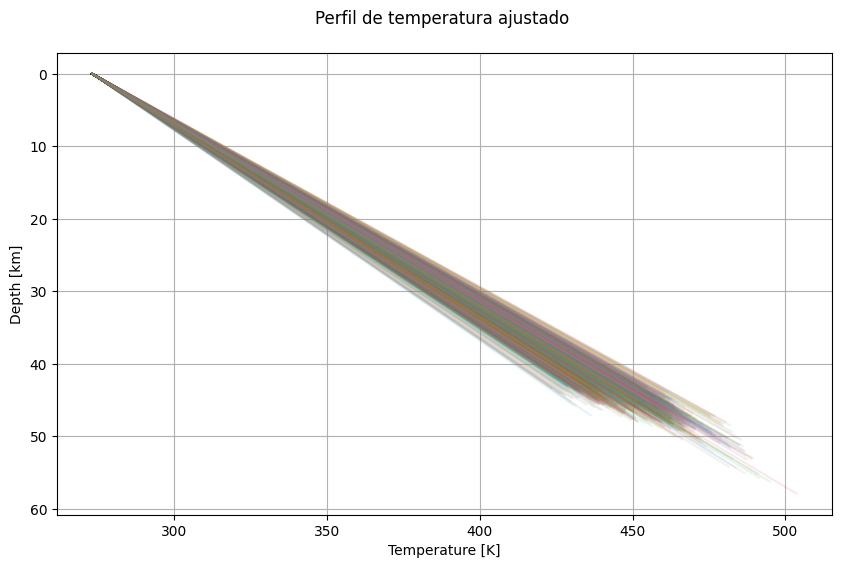

In [ ]:
plt.figure(figsize = (10, 6))

for n, df in df_crust.items():

  plt.plot(df['T_lin[K]'], df['Depth[km]'], alpha = 0.1)

plt.title('Perfil de temperatura ajustado \n')
plt.ylabel('Depth [km]')
plt.xlabel('Temperature [K]')

# plt.ylim(0, 50)
# plt.xlim(200, 600)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

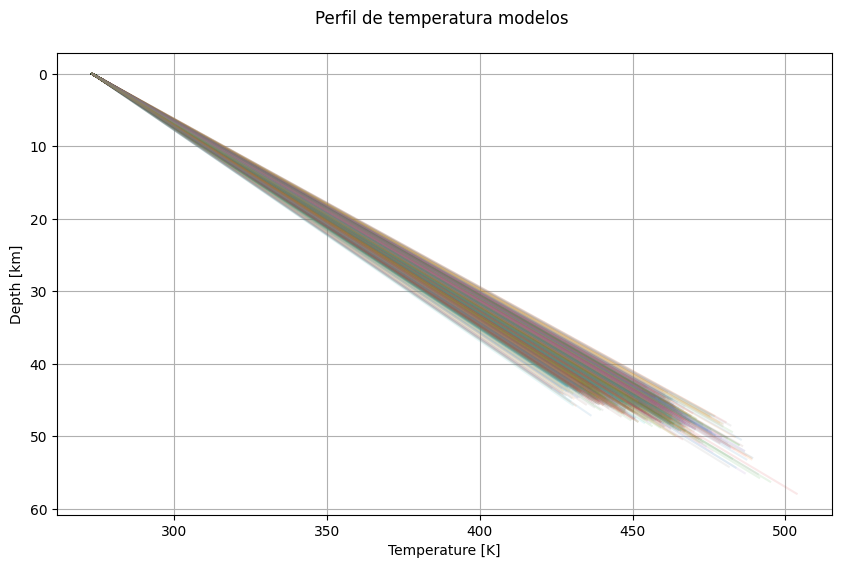

In [ ]:
plt.figure(figsize = (10, 6))

for n, df in df_crust.items():

  plt.plot(df['T[K]'], df['Depth[km]'], alpha = 0.1)

plt.title('Perfil de temperatura modelos \n')
plt.ylabel('Depth [km]')
plt.xlabel('Temperature [K]')

# plt.ylim(0, 50)
# plt.xlim(200, 600)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

#**Recolección de datos superficiales**

Vamos a tomar los datos superficiales para diferentes puntos de la órbita de Marte con el fin de realizar un promedio representativo de las condiciones climatológicas.

In [ ]:
#@title Rutina Lectura datos
def _is_float(tok: str) -> bool:
    try:
        float(tok)
        return True
    except Exception:
        return False

def leer_tabla_mcd(path_archivo: str) -> pd.DataFrame:
    """
    Lee una tabla del Mars Climate Database (MCD) con formato:
      - Una línea con '||' que contiene las latitudes (cabecera de columnas)
      - Varias líneas de datos con: <longitud> '||' <T(lat1)> <T(lat2)> ...
    y devuelve un DataFrame con:
      - Índice = Longitud Este (grados)
      - Columnas = Latitud Norte (grados)
      - Valores = Temperatura (K)
    """
    with open(path_archivo, "r", encoding="utf-8") as f:
        raw_lines = [l.strip() for l in f if l.strip()]

    latitudes = None
    rows = []

    for line in raw_lines:
        # Saltar comentarios con ###
        if line.startswith("#"):
            continue

        # Si no hay '||', no es útil para cabecera ni datos
        if "||" not in line:
            continue

        left, right = line.split("||", 1)
        left = left.strip()
        right = right.strip()

        # Si aún no hemos leído latitudes, intentamos extraerlas del primer '||' que veamos
        if latitudes is None:
            # La cabecera puede venir en una línea que empieza con '----'
            # y al final puede tener una barra de guiones '-----' o cosas no numéricas.
            # Tomamos todos los tokens de 'right' que sean flotantes hasta el primer no-flotante.
            cand = []
            for tok in right.split():
                if _is_float(tok):
                    cand.append(float(tok))
                else:
                    break

            if cand:
                latitudes = cand
                # Si además esa misma línea también contiene datos (raro pero posible si el formato es compacto),
                # intentamos interpretar 'left' como longitud y 'right' después de las latitudes como datos.
                # Para eso, reconstruimos la cola de 'right' saltando len(latitudes) floats.
                toks = right.split()
                tail = toks[len(latitudes):]
                if _is_float(left) and tail:
                    vals = []
                    for tok in tail:
                        if _is_float(tok):
                            vals.append(float(tok))
                        else:
                            break
                    if vals:
                        # Recortar o rellenar para casar con latitudes
                        if len(vals) > len(latitudes):
                            vals = vals[:len(latitudes)]
                        elif len(vals) < len(latitudes):
                            vals = vals + [math.nan] * (len(latitudes) - len(vals))
                        rows.append([float(left)] + vals)
            # Pasamos a la siguiente línea (ya sea que tuvimos o no datos pegados).
            continue

        # A partir de aquí, interpretamos filas de datos: "<lon> || <val ...>"
        if not _is_float(left):
            # Algunas líneas pueden tener separadores u otros textos a la izquierda; las saltamos
            continue

        lon = float(left)
        vals = []
        for tok in right.split():
            if _is_float(tok):
                vals.append(float(tok))
            else:
                break

        if not vals:
            continue

        # Asegurar longitud correcta frente a cortes de línea o arrastres
        if len(latitudes) is not None:
            if len(vals) > len(latitudes):
                vals = vals[:len(latitudes)]
            elif len(vals) < len(latitudes):
                vals = vals + [math.nan] * (len(latitudes) - len(vals))

        rows.append([lon] + vals)

    if latitudes is None:
        raise ValueError("No se pudieron detectar las latitudes (cabecera) en el archivo.")

    # Construir DataFrame
    df = pd.DataFrame(rows, columns=["Longitude"] + latitudes)
    df = df.drop_duplicates(subset=["Longitude"])
    df = df.sort_values("Longitude").set_index("Longitude")

    return df

##Datos del Equinoccio de Primavera (12 de noviembre de 2024)

In [ ]:
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/4450d537bf855a7a3ae8a707d64f090d.txt #Temperatura
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/ed2fcbf9ed0936ab68fae1fcb29f4b2c.txt #Presión

--2025-10-04 21:38:51--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/4450d537bf855a7a3ae8a707d64f090d.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48030 (47K) [text/plain]
Saving to: ‘4450d537bf855a7a3ae8a707d64f090d.txt’

4450d537bf855a7a3ae 100%[===================>]  46.90K   235KB/s    in 0.2s    

2025-10-04 21:38:52 (235 KB/s) - ‘4450d537bf855a7a3ae8a707d64f090d.txt’ saved [48030/48030]

--2025-10-04 21:38:52--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/ed2fcbf9ed0936ab68fae1fcb29f4b2c.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48028 (47K) [text/plain]
Saving to: ‘ed2fcbf9ed0936ab68fae1fcb29f4b2c.txt’

##Datos del solsticio de verano(30 de mayo de 2025)

In [ ]:
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/22dc9d495d7aa00a390334ee01ac4228.txt #Temperatura
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/50bcc358c3de8f51664cfbd8a68fcecf.txt #Presion

--2025-10-04 21:38:53--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/22dc9d495d7aa00a390334ee01ac4228.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48030 (47K) [text/plain]
Saving to: ‘22dc9d495d7aa00a390334ee01ac4228.txt’

22dc9d495d7aa00a390 100%[===================>]  46.90K   235KB/s    in 0.2s    

2025-10-04 21:38:53 (235 KB/s) - ‘22dc9d495d7aa00a390334ee01ac4228.txt’ saved [48030/48030]

--2025-10-04 21:38:54--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/50bcc358c3de8f51664cfbd8a68fcecf.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48028 (47K) [text/plain]
Saving to: ‘50bcc358c3de8f51664cfbd8a68fcecf.txt’

##Datos del equinoccio de otoño (29 de noviembre de 2025)

In [ ]:
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/c24bea297791d8db32f0d55af2a0d9bb.txt #Temperatura
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/37d3bd29b16c85c87df04dfbd1f43432.txt #Presión

--2025-10-04 21:38:54--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/c24bea297791d8db32f0d55af2a0d9bb.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48030 (47K) [text/plain]
Saving to: ‘c24bea297791d8db32f0d55af2a0d9bb.txt’

c24bea297791d8db32f 100%[===================>]  46.90K   235KB/s    in 0.2s    

2025-10-04 21:38:55 (235 KB/s) - ‘c24bea297791d8db32f0d55af2a0d9bb.txt’ saved [48030/48030]

--2025-10-04 21:38:55--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/37d3bd29b16c85c87df04dfbd1f43432.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48028 (47K) [text/plain]
Saving to: ‘37d3bd29b16c85c87df04dfbd1f43432.txt’

##Datos del solsticio de invierno(24 de abril de 2026)

In [ ]:
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/7c6c36781aa4d49cead94770817c6ab3.txt #Temperatura
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/17e6a86e842fe0be7b37c1c18ecb154a.txt #Presión

--2025-10-04 21:38:56--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/7c6c36781aa4d49cead94770817c6ab3.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48030 (47K) [text/plain]
Saving to: ‘7c6c36781aa4d49cead94770817c6ab3.txt’

7c6c36781aa4d49cead 100%[===================>]  46.90K   234KB/s    in 0.2s    

2025-10-04 21:38:56 (234 KB/s) - ‘7c6c36781aa4d49cead94770817c6ab3.txt’ saved [48030/48030]

--2025-10-04 21:38:56--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/17e6a86e842fe0be7b37c1c18ecb154a.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48028 (47K) [text/plain]
Saving to: ‘17e6a86e842fe0be7b37c1c18ecb154a.txt’

##**Lectura de datos y promedio**

Eq. Primavera

In [ ]:
temp_primav = '/content/4450d537bf855a7a3ae8a707d64f090d.txt'
pres_primav = '/content/ed2fcbf9ed0936ab68fae1fcb29f4b2c.txt'
T0_primav = leer_tabla_mcd(temp_primav)
P0_primav = leer_tabla_mcd(pres_primav)

Sols. Verano

In [ ]:
temp_verano = '/content/22dc9d495d7aa00a390334ee01ac4228.txt'
pres_verano = '/content/50bcc358c3de8f51664cfbd8a68fcecf.txt'
T0_verano = leer_tabla_mcd(temp_verano)
P0_verano = leer_tabla_mcd(pres_verano)

Eq. Otoño

In [ ]:
temp_otoño = '/content/c24bea297791d8db32f0d55af2a0d9bb.txt'
pres_otoño = '/content/37d3bd29b16c85c87df04dfbd1f43432.txt'
T0_otoño = leer_tabla_mcd(temp_otoño)
P0_otoño = leer_tabla_mcd(pres_otoño)

Sols. Invierno

In [ ]:
temp_invierno = '/content/7c6c36781aa4d49cead94770817c6ab3.txt'
pres_invierno = '/content/17e6a86e842fe0be7b37c1c18ecb154a.txt'
T0_invierno = leer_tabla_mcd(temp_invierno)
P0_invierno = leer_tabla_mcd(pres_invierno)

In [ ]:
#Temperaturas superficiales promedio en un año
T0_df = (T0_primav + T0_verano + T0_otoño + T0_invierno) / 4

#Presiones superficiales promedio en un año
P0_df = (P0_primav + P0_verano + P0_otoño + P0_invierno) / 4

Vamos a tomar el promedio de los modelos para el valor del gradiente de T

In [ ]:
#Promedio del gradiente de temperatura de los modelos
GT_mean = float(np.mean(list(T_slopes.values())))
#Separamos las profundidades máximas de cada modelo (MOHO)
moho_depths = {n: float(df['Depth[km]'].max()) for n, df in df_crust.items()}
#Promedio de las profundidades
moho_mean = float(np.mean(list(moho_depths.values())))

In [ ]:
def perfil_temperatura(df,GT_mean,moho_mean,dz=0.5)-> dict:

  z = np.arange(0.0,moho_mean+1e-9,dz)*1e3
  perfiles = {}

  for lon in df.index:
    for lat in df.columns:
      T0 = df.loc[lon, lat]
      Tz = T0 + GT_mean * z
      perfiles[(lat, lon)] = pd.DataFrame({
          "Depth[km]": z/1e3,
          "T[K]": Tz
      })
  return perfiles
temperaturas = perfil_temperatura(T0_df,GT_mean,moho_mean)

In [ ]:
perfil = temperaturas[(5.74468,134)]
perfil.head(100)

,Depth[km],T[K]
0,0.0,215.390750
1,0.5,217.330613
2,1.0,219.270475
3,1.5,221.210338
4,2.0,223.150200
...,...,...
86,43.0,382.218927
87,43.5,384.158789
88,44.0,386.098652
89,44.5,388.038515


In [ ]:
def prueba_modelos(modelo, perfil=None, alinear_T0=True):
    modelo_depth = df_crust[modelo]['Depth[km]']
    modelo_temp  = df_crust[modelo]['T[K]'].copy()

    if perfil is not None and alinear_T0:

        delta = float(perfil['T[K]'].iloc[0]) - float(modelo_temp.iloc[0])
        modelo_temp = modelo_temp + delta  #ajustamos temperaturas

    df_modelo = pd.DataFrame({
        'Depth[km]': modelo_depth,
        'T[K]': modelo_temp
    })
    return df_modelo

perfil = temperaturas[(5.74468, 134.0)]
df_m11 = prueba_modelos('11', perfil)
df_m11.head()

,Depth[km],T[K]
0,0.000,215.39075
1,10.780,256.43665
2,10.780,256.43665
3,29.086,326.14305
4,29.086,326.14305


In [ ]:
def comparar_perfiles(perfil, df_modelo):
    # interpolar modelo a las profundidades del perfil
    modelo_interp = np.interp(perfil['Depth[km]'],
                              df_modelo['Depth[km]'],
                              df_modelo['T[K]'])
    # calcular diferencia
    diferencia = perfil['T[K]'].values - modelo_interp
    return pd.DataFrame({
        "Depth[km]": perfil['Depth[km]'],
        "Perfil[K]": perfil['T[K]'],
        "Modelo[K]": modelo_interp,
        "Delta[K]": diferencia
    })
comparar_perfiles(perfil,df_m11)

,Depth[km],Perfil[K],Modelo[K],Delta[K]
0,0.0,215.390750,215.390750,0.000000
1,0.5,217.330613,217.294549,0.036064
2,1.0,219.270475,219.198347,0.072128
3,1.5,221.210338,221.102146,0.108191
4,2.0,223.150200,223.005945,0.144255
...,...,...,...,...
86,43.0,382.218927,379.124720,3.094207
87,43.5,384.158789,380.800150,3.358639
88,44.0,386.098652,380.800150,5.298502
89,44.5,388.038515,380.800150,7.238365


# **Pressure profile generalization**

In [ ]:
!wget https://www-mars.lmd.jussieu.fr/mcd_python/txt/a4e4ba4b96ddfbe753bd9ef229115eb1.txt

--2025-10-04 21:38:58--  https://www-mars.lmd.jussieu.fr/mcd_python/txt/a4e4ba4b96ddfbe753bd9ef229115eb1.txt
Resolving www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)... 134.157.47.37
Connecting to www-mars.lmd.jussieu.fr (www-mars.lmd.jussieu.fr)|134.157.47.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48087 (47K) [text/plain]
Saving to: ‘a4e4ba4b96ddfbe753bd9ef229115eb1.txt’

a4e4ba4b96ddfbe753b 100%[===================>]  46.96K   234KB/s    in 0.2s    

2025-10-04 21:38:59 (234 KB/s) - ‘a4e4ba4b96ddfbe753bd9ef229115eb1.txt’ saved [48087/48087]



In [ ]:
archivo = '/content/a4e4ba4b96ddfbe753bd9ef229115eb1.txt'
P0_df = leer_tabla_mcd(archivo)
P0_df.head(5)

,-90.0000,-86.1702,-82.3404,-78.5106,-74.6809,-70.8511,-67.0213,-63.1915,-59.3617,-55.5319,...,55.5319,59.3617,63.1915,67.0213,70.8511,74.6809,78.5106,82.3404,86.1702,90.0000
Longitude,,,,,,,,,,,,,,,,,,,,,
-180.0,1.18076,1.83820,2.10476,2.59812,3.05231,3.21083,3.26970,3.05394,3.31561,3.12609,...,6.74275,7.42494,7.76849,7.73550,7.81523,7.96271,7.98130,7.34221,6.01909,4.85696
-174.0,1.18077,1.67763,2.11698,2.64927,3.18401,3.53398,3.11522,3.16126,3.02071,3.28591,...,6.59305,7.45486,7.70668,7.86529,8.02471,8.10670,7.99771,7.31167,6.05377,4.86352
-168.0,1.18073,1.71257,2.11781,2.67615,3.11881,3.77268,3.49002,3.31926,3.22412,3.10450,...,6.48084,7.36477,7.77366,7.99235,8.09524,8.28873,8.01519,7.29510,6.15189,4.85990
-162.0,1.18223,1.74471,2.11799,2.65982,3.21435,3.85524,3.77773,3.59756,3.09758,3.19927,...,6.28789,7.22512,7.71991,8.01213,8.24309,8.36489,8.06920,7.31794,5.94874,4.86183
-157.0,1.17961,1.73811,2.11292,2.67443,3.73673,3.68681,3.93668,3.62730,3.20947,3.08655,...,5.95087,6.99508,7.56434,7.97549,8.31336,8.47866,8.16292,7.36046,5.95366,4.85496


In [ ]:
def prueba_modelos(modelo, perfil=None, alinear_P0=True):
    modelo_depth = df_crust[modelo]['Depth[km]']
    modelo_press  = df_crust[modelo]['P[Pa]'].copy()

    if perfil is not None and alinear_P0:

        delta = float(perfil['P[Pa]'].iloc[0]) - float(modelo_press.iloc[0])
        modelo_press = modelo_press + delta  #ajustamos presiones

    df_modelo = pd.DataFrame({
        'Depth[km]': modelo_depth,
        'P[Pa]': modelo_press
    })
    return df_modelo

In [ ]:
def comparar_perfiles(perfil, df_modelo):
    # interpolar modelo a las profundidades del perfil
    modelo_interp = np.interp(perfil['Depth[km]'],
                              df_modelo['Depth[km]'],
                              df_modelo['P[Pa]'])
    # calcular diferencia
    diferencia = perfil['P[Pa]'].values - modelo_interp
    return pd.DataFrame({
        "Depth[km]": perfil['Depth[km]'],
        "Perfil[Pa]": perfil['P[Pa]'],
        "Modelo[Pa]": modelo_interp,
        "Delta[Pa]": diferencia
    })
df_comparacion = comparar_perfiles(perfil,df_m11)
# Mostrar sin notación científica en esa columna
df_comparacion["Delta[Pa]"] = df_comparacion["Delta[Pa]"].apply(lambda x: f"{x:,.0f}")
df_comparacion

##**Función de integración para la presión**


In [ ]:
#Función integradora
def sistema(y, r,f_rho):
  G = c.G.value

  rho = f_rho(r)
  g, m, P = y

  dm = 4*np.pi*(r**2)*rho
  dg = 4*np.pi*G*rho - (2*G*m/(r**3))
  dP = -rho*g
  return np.array([dg, dm, dP])

def integracion_presion(P0_mars):
  #Radio Marte
  R_mars = 0.533*c.R_earth.value

  # Valores superficiales
  m0 = 0.107*c.M_earth.value
  g0 = (c.G.value*m0/((R_mars)**2))

  # Condiciones Iniciales
  y0 = np.array([g0 , m0, P0_mars])

  #Radio y densidad promedio de todos los modelos
  #Se usó un modelo aleatorio como primera aproximación
  rhos = df_crust['500']['Rho[g/cm3]']*1e3 # kg/m3
  radius = R_mars - df_crust['500']['Depth[km]']*1e3 # m

  #Organización de datos para el interpolador
  #El interpolador necesita los datos en orden.
  sort_indices = np.argsort(radius)
  radius_interp = radius.iloc[sort_indices]
  rhos_interp = rhos.iloc[sort_indices]
  r = radius_interp.to_numpy()
  rho = rhos_interp.to_numpy()

  # Interpolador
  f_rho = interp1d(r,
                   rho,
                   bounds_error=False,
                   fill_value = (rho[0], rho[-1]))

  #Solución al sistema
  sol = odeint(sistema, y0, radius,args=(f_rho,)).T

  # Pressure
  return sol[2] #Pa

In [ ]:
def perfil_presion(P0_df,dz=0.5)-> dict:

  perfiles = {}
  for lon in P0_df.index:
    for lat in P0_df.columns:
      #Tomamos la presión superficial
      P0 = P0_df.loc[lon, lat]
      #Calculamos la presión
      presion = integracion_presion(P0)
      #Guardamos la presión

      perfiles[(lat, lon)] = presion
  return perfiles
presiones = perfil_presion(P0_df)

In [ ]:
df_crust['500']['P[Pa]']

,P[Pa]
0,0.000000e+00
1,7.335013e+07
2,7.335013e+07
3,1.850376e+08
4,1.850376e+08
5,3.746295e+08
6,3.746295e+08


In [ ]:
presiones[(5.74468, 134)]

array([4.27788000e-01, 8.01648783e+07, 8.01648783e+07, 2.04234860e+08,
       2.04234860e+08, 3.64221747e+08, 3.64221747e+08])

###**Interpolación de los datos**

Falta hacer la interpolación de los datos para las mismas profundidades que se usan en la temperatura (la columna depth debe tener los mismos valores para

In [ ]:
PRESIONES = {}
for lon in P0_df.index:
  for lat in P0_df.columns:
    if len(df.index) == 7 :
      P_ser = pd.Series(presiones[(lat,lon)], index = df.index)
      radius = df_crust["500"]['Depth[km]']*1e3  # m
      sort_indices = np.argsort(radius)
      z = radius.iloc[sort_indices].to_numpy()
      P = P_ser.iloc[sort_indices].to_numpy()
      #Fitting
      P_interpolado = interp1d(
        z, P,
        bounds_error=False,
        fill_value=(P[0], P[-1])
    )
      ## Tomamos los mismos radios de temperatura para que la interpolacion
      ## quede conjunta con la de T
      temp = temperaturas[(lat,lon)]
      z = temp['Depth[km]'].to_numpy()*1e3
      P_eval = P_interpolado(z)
      PRESIONES[(lat, lon)] = pd.DataFrame({"Depth[km]": z/1e3, "P[Pa]": P_eval})

In [ ]:
perfil = PRESIONES[(5.74468, 134)]
df_m11 = prueba_modelos('11', perfil)

Comparación del ajuste integrado con el ajuste lineal

In [ ]:
comparacion_ajustes = comparar_perfiles(PRESIONES[(5.74468, 134.0)],df_m11)
comparacion_ajustes['Delta[Pa]'] = comparacion_ajustes['Delta[Pa]'].apply(lambda x: f"{x:,.0f}")
comparacion_ajustes

,Depth[km],Perfil[Pa],Modelo[Pa],Delta[Pa]
0,0.0,4.277880e-01,4.277880e-01,0
1,0.5,3.425557e+06,3.091080e+06,"334,477"
2,1.0,6.851114e+06,6.182160e+06,"668,954"
3,1.5,1.027667e+07,9.273240e+06,"1,003,430"
4,2.0,1.370223e+07,1.236432e+07,"1,337,907"
...,...,...,...,...
86,43.0,3.544981e+08,3.748703e+08,"-20,372,212"
87,43.5,3.590334e+08,3.795335e+08,"-20,500,104"
88,44.0,3.635687e+08,3.795335e+08,"-15,964,815"
89,44.5,3.642217e+08,3.795335e+08,"-15,311,733"


# **Phase Diagram**

### **IAPWS Package**

In [ ]:
!pip install -Uq iapws

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import iapws

In [ ]:
from iapws import IAPWS97
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure

In [ ]:
# Sublimation of Ih Ice
Ts_subl = np.linspace(60, 273.16, 100)
Ps_subl = [_Sublimation_Pressure(T) for T in Ts_subl]

# Vaporization of Liquid Water
Ts_vap = np.linspace(273.16, 647.096, 100)
Ps_vap = [IAPWS97(T = T, x = 0).P for T in Ts_vap] # x = 0 (Saturation)

# Melting of Ih Ice
Ts_melt_Ih = np.linspace(251.165, 273.16, 100)  #
Ps_melt_Ih = [_Melting_Pressure(T, ice = "Ih") for T in Ts_melt_Ih]

# Melting of III Ice
Ts_melt_III = np.linspace(251.166, 256.164, 100)
Ps_melt_III = [_Melting_Pressure(T, ice = "III") for T in Ts_melt_III]

# Melting of V Ice
Ts_melt_V = np.linspace(256.165, 273.15, 100)
Ps_melt_V = [_Melting_Pressure(T, ice = "V") for T in Ts_melt_V]

# Melting of VI Ice
Ts_melt_VI = np.linspace(273.32, 355, 100)
Ps_melt_VI = [_Melting_Pressure(T, ice = "VI") for T in Ts_melt_VI]

# Melting of VII Ice
Ts_melt_VII = np.linspace(355.1, 647.096, 100)  # VII Ice
Ps_melt_VII = [_Melting_Pressure(T, ice = "VII") for T in Ts_melt_VII]

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


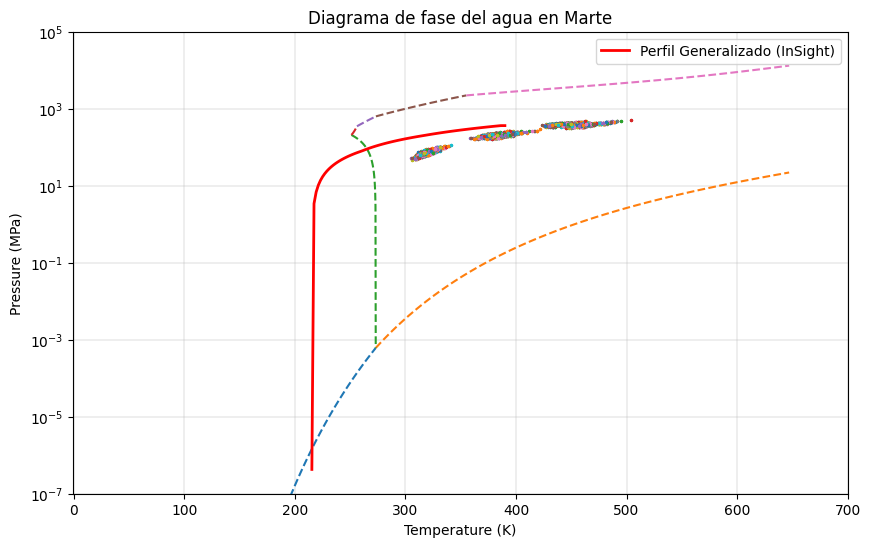

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(Ts_subl, Ps_subl,'--')
plt.plot(Ts_vap, Ps_vap,'--')
plt.plot(Ts_melt_Ih, Ps_melt_Ih,'--')
plt.plot(Ts_melt_III, Ps_melt_III,'--')
plt.plot(Ts_melt_V, Ps_melt_V,'--')
plt.plot(Ts_melt_VI, Ps_melt_VI,'--')
plt.plot(Ts_melt_VII, Ps_melt_VII,'--')

# Plot Data
for n, df in df_crust.items():
  plt.scatter(df['T[K]'], df['P[Pa]']/1e6, s = 2)

plt.yscale('log')
plt.ylim(1e-7, 100000)
plt.xlim(-1, 700)

plt.title('Diagrama de fase del agua en Marte')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (MPa)')

plt.grid(True, lw = 0.3)
##Locación para datos del insight:
perfil_T = temperaturas[(5.74468, 134)]
perfil_P = PRESIONES[(5.74468, 134)]
##Locación para el polo sur
#perfil_T = temperaturas[(-90.0, -88.0)]
#perfil_P = presiones[(-90.0, -88.0)]
plt.plot(perfil_T['T[K]'], perfil_P['P[Pa]']/1e6, color='red', linewidth=2, label='Perfil Generalizado (InSight)')
plt.legend()
plt.show()

Gráfica hecha para el póster

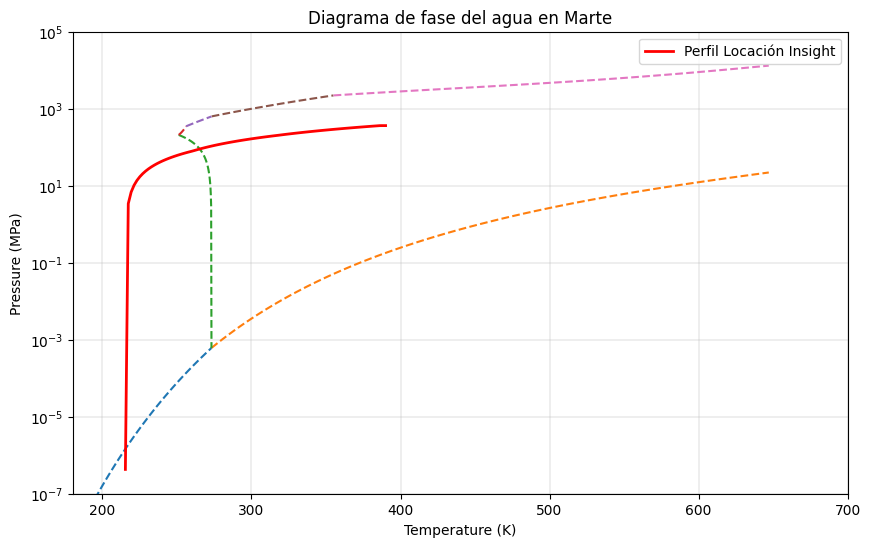

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(Ts_subl, Ps_subl,'--')
plt.plot(Ts_vap, Ps_vap,'--')
plt.plot(Ts_melt_Ih, Ps_melt_Ih,'--')
plt.plot(Ts_melt_III, Ps_melt_III,'--')
plt.plot(Ts_melt_V, Ps_melt_V,'--')
plt.plot(Ts_melt_VI, Ps_melt_VI,'--')
plt.plot(Ts_melt_VII, Ps_melt_VII,'--')

plt.yscale('log')
plt.ylim(1e-7, 100000)
plt.xlim(180, 700)

plt.title('Diagrama de fase del agua en Marte')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (MPa)')

plt.grid(True, lw = 0.3)
##Locación para datos del insight:
perfil_T = temperaturas[(5.74468, 134)]
perfil_P = PRESIONES[(5.74468, 134)]
##Locación para el polo sur
#perfil_T = temperaturas[(-90.0, -88.0)]
#perfil_P = presiones[(-90.0, -88.0)]
plt.plot(perfil_T['T[K]'], perfil_P['P[Pa]']/1e6, color='red', linewidth=2, label='Perfil Locación Insight')
plt.legend()
plt.show()

Para insight

In [ ]:
from scipy.optimize import minimize_scalar
melt_depths = {}

f_melt = interp1d(Ts_melt_Ih, Ps_melt_Ih) # In MPa

for n, df in df_crust.items():

  # Profiles Interpolation
  f_depth = interp1d(perfil_T['T[K]'], perfil_P['Depth[km]'],
                     fill_value = 'extrapolate')

  f_P = interp1d(perfil_T['T[K]'], perfil_P['P[Pa]']/1e6, fill_value = 'extrapolate')


  melt_depths[n] = f_depth(minimize_scalar(lambda x: abs(f_P(x) - f_melt(x)),
                                           bounds = (251.165, 273.16),
                                           method='bounded').x).max()

In [ ]:
mean_depth = np.mean(list(melt_depths.values()))

print(f'Mean Depth: {mean_depth:.2f} km')

Mean Depth: 12.85 km


## **Finding Melt Transition Depth**

In [ ]:
from scipy.optimize import minimize_scalar

In [ ]:
melt_depths = {}

f_melt = interp1d(Ts_melt_Ih, Ps_melt_Ih) # In MPa

for n, df in df_crust.items():

  # Profiles Interpolation
  f_depth = interp1d(df['T[K]'], df['Depth[km]'],
                     fill_value = 'extrapolate')

  f_P = interp1d(df['T[K]'], df['P[Pa]']/1e6, fill_value = 'extrapolate')


  melt_depths[n] = f_depth(minimize_scalar(lambda x: abs(f_P(x) - f_melt(x)),
                                           bounds = (251.165, 273.16),
                                           method='bounded').x).max()

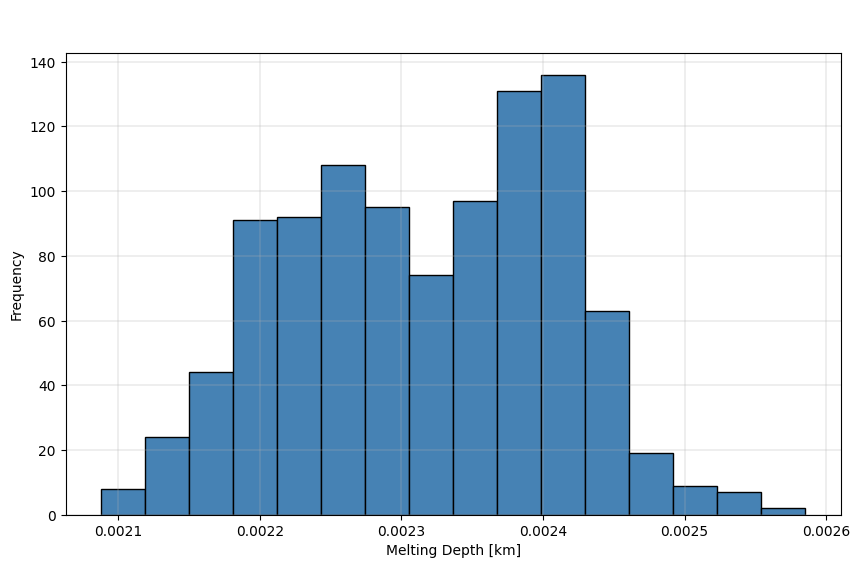

In [ ]:
plt.figure(figsize = (10, 6))

plt.hist(list(melt_depths.values()), bins = 'scott',
         color = 'steelblue', edgecolor = 'black')

plt.title('\n')
plt.xlabel('Melting Depth [km]')
plt.ylabel('Frequency')

plt.grid(True, lw = 0.3)

plt.show()

In [ ]:
mean_depth = np.mean(list(melt_depths.values()))

print(f'Mean Depth: {mean_depth:.2f} km')

#Sacamos todos los perfiles, no solo el de insight

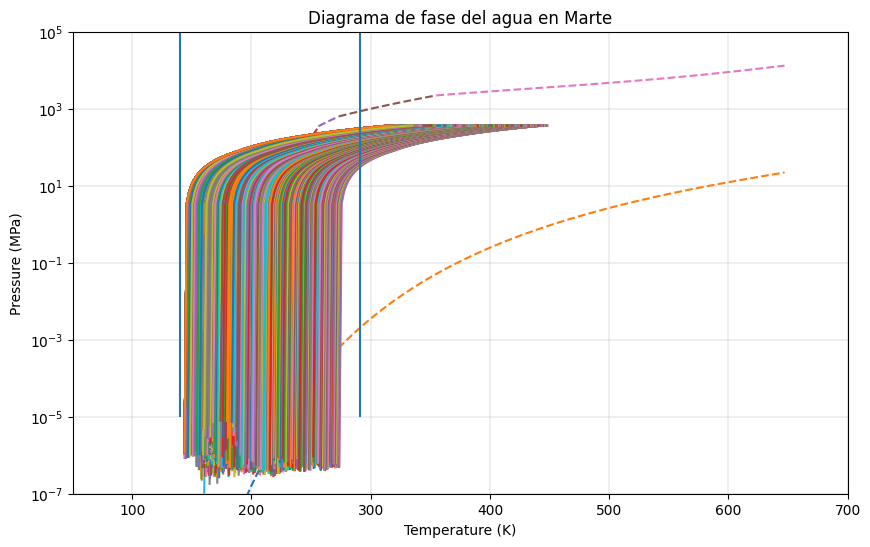

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(Ts_subl, Ps_subl,'--')
plt.plot(Ts_vap, Ps_vap,'--')
plt.plot(Ts_melt_Ih, Ps_melt_Ih,'--')
plt.plot(Ts_melt_III, Ps_melt_III,'--')
plt.plot(Ts_melt_V, Ps_melt_V,'--')
plt.plot(Ts_melt_VI, Ps_melt_VI,'--')
plt.plot(Ts_melt_VII, Ps_melt_VII,'--')

# Plot Data

plt.yscale('log')
plt.ylim(1e-7, 100000)
plt.xlim(50, 700)

plt.title('Diagrama de fase del agua en Marte')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (MPa)')

plt.grid(True, lw = 0.3)

for lon in P0_df.index:
  for lat in P0_df.columns:
    plt.plot(temperaturas[(lat,lon)]['T[K]'], PRESIONES[(lat,lon)]['P[Pa]']/1e6)#

plt.vlines(291,1e-5,1e5) ##condiciones iniciales de los datos
plt.vlines(140,1e-5,1e5)
plt.show()

In [ ]:
melt_depths = {}

# Interpolación de ambas curvas de transición
f_melt = interp1d(Ts_melt_Ih, Ps_melt_Ih, fill_value='extrapolate')
f_vap = interp1d(Ts_vap, Ps_vap, fill_value='extrapolate')

# Convertimos curva de transición en puntos discretos (densa)
T_curve = np.linspace(min(Ts_melt_Ih), max(Ts_melt_Ih), 1000)
P_curve = f_melt(T_curve)
T_vap = np.linspace(min(Ts_vap), max(Ts_vap), 1000)
P_vap = f_vap(T_vap)

curve_vap = np.vstack([T_vap, P_vap]).T
curve_points = np.vstack([T_curve, P_curve]).T

In [ ]:
for lon in P0_df.index:
    for lat in P0_df.columns:
        # Perfil interpolado
        T_prof = temperaturas[(lat, lon)]['T[K]'].values
        P_prof = PRESIONES[(lat, lon)]['P[Pa]'].values / 1e6
        D_prof = PRESIONES[(lat, lon)]['Depth[km]'].values

        profile_points = np.vstack([T_prof, P_prof]).T

        if temperaturas[(lat,lon)]['T[K]'][0] <= max(Ts_melt_Ih):
          # Calculamos todas las distancias entre perfil y curva
          dist_matrix = cdist(profile_points, curve_points)
          # Encontramos el par más cercano
          i_prof, j_curve = np.unravel_index(dist_matrix.argmin(), dist_matrix.shape)

        if temperaturas[(lat,lon)]['T[K]'][0] > max(Ts_melt_Ih):
          dist_matrix = cdist(profile_points, curve_vap)
          # Encontramos el par más cercano
          i_prof, j_curve = np.unravel_index(dist_matrix.argmin(), dist_matrix.shape)

        # Guardamos la profundidad correspondiente
        melt_depths[(lat, lon)] = D_prof[i_prof]

In [ ]:
hay_negativos = any(v < 0 for v in melt_depths.values())
print(hay_negativos)

(array([ 26.,  34.,  58.,  57.,  30.,  49.,  50.,  55.,  64.,  34.,  74.,
         77.,  76.,  96.,  43.,  88.,  91., 106., 118.,  69., 165., 172.,
        220., 255., 152., 326., 319.,  56.,  25.,  87.]),
 array([ 0. ,  0.9,  1.8,  2.7,  3.6,  4.5,  5.4,  6.3,  7.2,  8.1,  9. ,
         9.9, 10.8, 11.7, 12.6, 13.5, 14.4, 15.3, 16.2, 17.1, 18. , 18.9,
        19.8, 20.7, 21.6, 22.5, 23.4, 24.3, 25.2, 26.1, 27. ]),
 <BarContainer object of 30 artists>)

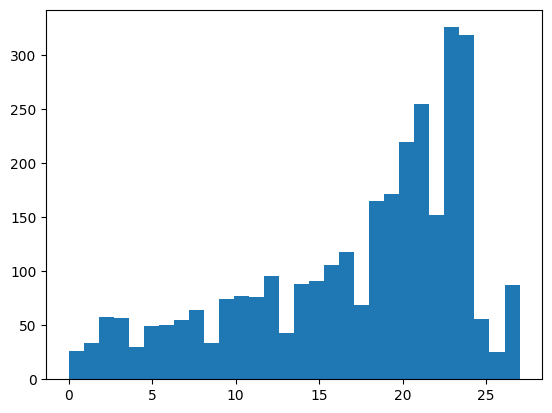

In [ ]:
plt.hist(melt_depths.values(),bins=30) ## Hacemos un histograma de los valores de transicion

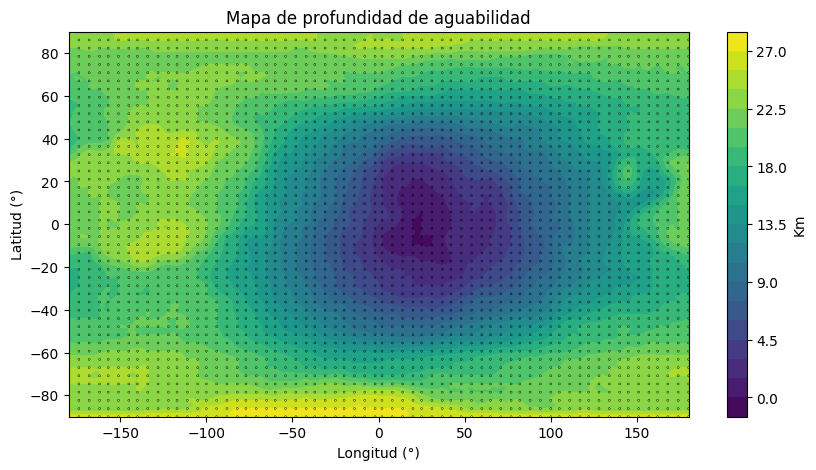

In [ ]:
from scipy.interpolate import griddata
import matplotlib.image as mpimg

def plot_martian_heatmap(coords, depths,
                         resolution=300,
                         method='cubic',
                         contour_levels=20,
                         cmap='viridis',
                         show_points=True,
                         point_size=2,
                         figsize=(10,5),
                         title='Mapa de profundidad de aguabilidad'):
    # Convertir a arrays
    coords = np.array(coords)
    depths = np.array(depths)
    lat = coords[:,0]
    lon = coords[:,1]
    # Crear rejilla regular en lat-lon
    lon_grid = np.linspace(lon.min(), lon.max(), resolution)
    lat_grid = np.linspace(lat.min(), lat.max(), resolution)
    Lon_grid, Lat_grid = np.meshgrid(lon_grid, lat_grid)
    ## Interpolación (griddata)
    Z = griddata((lon, lat), depths, (Lon_grid, Lat_grid), method=method)

    fig, ax = plt.subplots(figsize=figsize)
    cf = ax.contourf(Lon_grid, Lat_grid, Z, levels=contour_levels, cmap=cmap)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label('Km')
    sc = ax.scatter(lon, lat, c=depths, s=point_size, edgecolor='k', linewidth=0.3)
    ax.set_xlabel('Longitud (°)')
    ax.set_ylabel('Latitud (°)')
    ax.set_title(title)
    ax.set_aspect('auto')
    plt.show()

    return Z

coords = list(PRESIONES.keys())
depths = list(melt_depths.values())
Z =plot_martian_heatmap(coords, depths, resolution=400, method='cubic')